# SFT Results — Dolci capability settings (Qwen3-1.7B-Base)

Companion to `result.ipynb` (paper settings). Same cells and figure style; only the settings differ.
Run all cells to generate the figures under `figures/` and the result tables.

In [8]:
import json
import os
import re
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')


In [9]:
# ============================================
# Configuration (Dolci capability settings on Qwen3-1.7B-Base; fixed LRs)
# ============================================
SCRATCH_DIR = os.environ.get('SCRATCH_DIR', '/workspace-vast/pbb/scratch')
out_dir = f'{SCRATCH_DIR}/Dr.Post-Training/SFT/runs'
config_base = './train/configs'
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

default_model = 'Qwen/Qwen3-1.7B-Base'

def _model_short(hf_name):
    return hf_name.split('/')[-1]

# Settings. `config` is the dir under train/configs/, `prefix` is the run-dir
# prefix ({train}_{task}). DATASETS is filled from DOLCI_SETTINGS x DOLCI_KS below.
#
# Per-setting keys:
#   model  — HF model name when not `default_model` (run dirs embed its short name)
#   n_val  — D* size when not SHARED_CONFIG['n_val']
#   k      — selection keep-rate of the curation arms (top-k of the 8 candidates per
#            step). Method yamls: k=0.5 is the unsuffixed default, 0.25 -> '-f25',
#            0.75 -> '-f75' (see K_SUFFIX). FullTraining ignores k.
#   key    — dict key / figure-file stem when one config appears with several k.
#
# Optional per-setting visual clipping for the trajectory plots:
#   y_clip_max_ppl  — caps eval-perplexity y-axis (e.g. triviaqa_nq baseline
#                     starts at ~174 ppl; clipping at 25 makes the late-step
#                     dynamics visible).
#   y_clip_max_loss — caps eval-loss y-axis equivalently.
DATASETS = []
K_SUFFIX = {0.25: '-f25', 0.5: '', 0.75: '-f75'}

def ds_key_of(ds):
    return ds.get('key', ds['config'])

SHARED_CONFIG = {'batch_size': 8, 'n_val': 16}
SEEDS = [2, 22, 42, 62, 82]

# Group-wise curation (2026-09: GroupWiseSubset with selection_granularity block / sublayer;
# yamls {Block,Sublayer}WiseSubset-Full{,-f25,-f75} in every dolci_* config dir). Runs that do
# not exist yet are skipped by the loaders, so the list can stay complete.
CURATIONS = ['FullTraining', 'GlobalSubset', 'LayerWiseSubset', 'BlockWiseSubset', 'SublayerWiseSubset']

LEGEND_NAMES = {
    'FullTraining':    'Full-Training',
    'GlobalSubset':    'Global Subset',
    'LayerWiseSubset': 'Layer-Wise Subset',
    'BlockWiseSubset': 'Block-Wise Subset',
    'SublayerWiseSubset': 'Sublayer-Wise Subset',
    'TargetOnly':      'Target-only',
}
METHOD_COLORS = {
    'FullTraining':    'black',
    'GlobalSubset':    'green',
    'LayerWiseSubset': 'red',
    'BlockWiseSubset': 'darkorange',
    'SublayerWiseSubset': 'purple',
    'TargetOnly':      'blue',
}

DATASET_TITLES = {}

# Target-only run-dir prefix is `<task>_val_<task>` and `ms<max_steps>` (per
# train_val_ablation.sh). Filled from DOLCI_SETTINGS below.
TARGET_ONLY = []

# ---------------------------------------------------------------------------
# Dolci capability settings (Qwen3-1.7B-Base): 32K-row Dolci-Instruct pool -> 128-row D*
# held out from the pool's own source; benchmarks scored greedily on the final checkpoint
# (IFEval/IFBench or MATH500/GSM8K). Every setting is included at every keep-rate k, one
# DATASETS entry per (setting, k) with key `<config>_k<k*100>` (e.g. dolci_mixed_if_k75).
# Target-only trains on the 128 D* rows for 4000 steps (= the main runs' 32,000 rows / bs 8)
# and does not depend on the pool or k, so the same run is attached to every matching entry.
# ---------------------------------------------------------------------------
DOLCI_MODEL = 'Qwen/Qwen3-1.7B-Base'
DOLCI_N_VAL = 128
DOLCI_KS = [0.25, 0.5, 0.75]
DOLCI_SETTINGS = [
    # (config dir,                run-dir prefix,                 train pool,          target,         title)
    ('dolci_inst_if',            'dolci_instruction_precise_if', 'dolci_instruction', 'precise_if',   'dolci-instruction → precise IF'),
    ('dolci_mixed_if',           'dolci_mixed_precise_if',       'dolci_mixed',       'precise_if',   'dolci-mixed → precise IF'),
    ('dolci_reason_mathpersona', 'dolci_reasoning_math_persona', 'dolci_reasoning',   'math_persona', 'dolci-reasoning → math'),
    ('dolci_mixed_mathpersona',  'dolci_mixed_math_persona',     'dolci_mixed',       'math_persona', 'dolci-mixed → math'),
]
for config, prefix, train, task, title in DOLCI_SETTINGS:
    for k in DOLCI_KS:
        key = f'{config}_k{int(round(k * 100))}'
        DATASETS.append({'config': config, 'prefix': prefix, 'train': train, 'task': task, 'percentage': 1.0,
                         'finetunings': ['Full'], 'model': DOLCI_MODEL, 'n_val': DOLCI_N_VAL, 'k': k, 'key': key})
        DATASET_TITLES[key] = f'{title} (k={k})'
        TARGET_ONLY.append({'main_ds_key': key, 'task': task, 'max_steps': 4000, 'finetunings': ['Full'],
                            'model': DOLCI_MODEL, 'n_val': DOLCI_N_VAL})

# Benchmark metrics: a `metrics` dict {name: (result_file, key)}; all are greedy-decoding
# accuracies on a 0–100 scale read from the final checkpoint's result files. (A task may
# alternatively give one `result_file` plus a `metrics` list, as in result.ipynb.)
TASK_METRICS = {
    'precise_if':   {'metrics': {'ifeval_strict':  ('ifeval_results.greedy.json',  'prompt_level_strict_acc'),
                                 'ifeval_loose':   ('ifeval_results.greedy.json',  'prompt_level_loose_acc'),
                                 'ifbench_loose':  ('ifbench_results.greedy.json', 'prompt_level_loose_acc'),
                                 'ifbench_strict': ('ifbench_results.greedy.json', 'prompt_level_strict_acc')},
                     'primary': 'ifeval_strict'},
    'math_persona': {'metrics': {'math500': ('math500_results.greedy.json', 'accuracy'),
                                 'gsm8k':   ('gsm8k_results.greedy.json',   'accuracy')},
                     'primary': 'gsm8k'},
}

def task_metric_specs(task):
    """{metric_name: (result_file, json_key)} for a task, whichever form TASK_METRICS uses."""
    spec = TASK_METRICS[task]
    if isinstance(spec['metrics'], dict):
        return spec['metrics']
    return {m: (spec['result_file'], m) for m in spec['metrics']}

print(f'Datasets: {len(DATASETS)}')
for ds in DATASETS:
    print(f"  {ds_key_of(ds):28s} → {ds['prefix']:30s} "
          f"({ds['train']} → {ds['task']}, p={ds['percentage']}, ft={ds['finetunings']}"
          + (f", k={ds['k']}" if 'k' in ds else '') + ')')

Datasets: 12
  dolci_inst_if_k25            → dolci_instruction_precise_if   (dolci_instruction → precise_if, p=1.0, ft=['Full'], k=0.25)
  dolci_inst_if_k50            → dolci_instruction_precise_if   (dolci_instruction → precise_if, p=1.0, ft=['Full'], k=0.5)
  dolci_inst_if_k75            → dolci_instruction_precise_if   (dolci_instruction → precise_if, p=1.0, ft=['Full'], k=0.75)
  dolci_mixed_if_k25           → dolci_mixed_precise_if         (dolci_mixed → precise_if, p=1.0, ft=['Full'], k=0.25)
  dolci_mixed_if_k50           → dolci_mixed_precise_if         (dolci_mixed → precise_if, p=1.0, ft=['Full'], k=0.5)
  dolci_mixed_if_k75           → dolci_mixed_precise_if         (dolci_mixed → precise_if, p=1.0, ft=['Full'], k=0.75)
  dolci_reason_mathpersona_k25 → dolci_reasoning_math_persona   (dolci_reasoning → math_persona, p=1.0, ft=['Full'], k=0.25)
  dolci_reason_mathpersona_k50 → dolci_reasoning_math_persona   (dolci_reasoning → math_persona, p=1.0, ft=['Full'], k=0.5)
  dolci_

## Helper Functions & Load All Data


In [10]:
# ============================================
# LR lookup from each method's YAML, falling back to defaults.yaml.
# ============================================
def load_lr_from_yaml(config_name, method_name):
    method_yaml = os.path.join(config_base, config_name, f'{method_name}.yaml')
    if os.path.exists(method_yaml):
        with open(method_yaml) as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    defaults_yaml = os.path.join(config_base, config_name, 'defaults.yaml')
    if os.path.exists(defaults_yaml):
        with open(defaults_yaml) as f:
            cfg = yaml.safe_load(f)
        if cfg and 'learning_rate' in cfg:
            return cfg['learning_rate']
    return None


def _format_lr_main(lr):
    """Main-run LR format (matches train.sh): scientific with 2 decimals (1.00e-05)."""
    if lr is None:
        return None
    return f'{float(lr):.2e}'


def _format_lr_target(lr):
    """Target-only LR format (matches train_val_ablation.sh): 1e-05 (no decimals)."""
    if lr is None:
        return None
    return f'{float(lr):.0e}'


# Cache LRs from YAML so we don't reparse on every dir-name lookup.
_lr_cache = {}
for ds in DATASETS:
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            method = f'{cur}-{ft}'
            lr = load_lr_from_yaml(ds['config'], method)
            _lr_cache[(ds['config'], method)] = lr


def main_dir(ds, curation, ft, seed):
    method = f'{curation}-{ft}'
    lr_raw = _lr_cache.get((ds['config'], method))
    lr = _format_lr_main(lr_raw) or ('1.00e-04' if ft == 'LoRA' else '1.00e-05')
    cfg = SHARED_CONFIG
    # Curation arms carry the keep-rate suffix of their method yaml (e.g. GlobalSubset-Full-f75).
    suffix = K_SUFFIX[ds['k']] if ('k' in ds and curation != 'FullTraining') else ''
    return (f"{ds['prefix']}-{_model_short(ds.get('model', default_model))}-{method}{suffix}"
            f"-p{ds['percentage']}-lr{lr}-b{cfg['batch_size']}-v{ds.get('n_val', cfg['n_val'])}-s{seed}")


def target_dir(ta, ft, seed):
    # Target-only LR follows the FullTraining recipe (Full/MeSO=1e-05, LoRA=1e-04).
    lr = '1e-04' if ft == 'LoRA' else '1e-05'
    cfg = SHARED_CONFIG
    task = ta['task']
    return (f"{task}_val_{task}-{_model_short(ta.get('model', default_model))}-FullTraining-{ft}"
            f"-ms{ta['max_steps']}-lr{lr}-b{cfg['batch_size']}-v{ta.get('n_val', cfg['n_val'])}-s{seed}")


def _load_eval_results(path):
    with open(path) as f:
        data = json.load(f)
    steps = [item['step'] for item in data]
    val_ppl = [item['val_perplexity'] for item in data]
    eval_ppl = [item['eval_perplexity'] for item in data]
    eval_loss = [item['eval_loss'] for item in data]
    wt = [item.get('wall_time') for item in data]
    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_ppl),
        'eval_perplexity': np.array(eval_ppl),
        'eval_loss': np.array(eval_loss),
        'wall_time': np.array(wt) if all(t is not None for t in wt) else None,
    }


def _aggregate(runs):
    """Stack per-seed traces, return mean / SE / step axis."""
    if not runs:
        return None
    n = len(runs)
    se_denom = np.sqrt(n)
    min_len = min(len(r['steps']) for r in runs)
    out = {'steps': runs[0]['steps'][:min_len], 'n_seeds': n}
    for k in ['val_perplexity', 'eval_perplexity', 'eval_loss']:
        arr = np.stack([r[k][:min_len] for r in runs])
        out[f'{k}_mean'] = np.mean(arr, axis=0)
        out[f'{k}_std']  = np.std(arr, axis=0) / se_denom
    if all(r['wall_time'] is not None for r in runs):
        wt = np.stack([r['wall_time'][:min_len] for r in runs])
        out['wall_time_mean'] = np.mean(wt, axis=0)
        out['wall_time_std']  = np.std(wt, axis=0) / se_denom
    else:
        out['wall_time_mean'] = None
        out['wall_time_std']  = None
    return out


def collect_main(ds, curation, ft):
    runs = []
    for s in SEEDS:
        d = f"{out_dir}/{main_dir(ds, curation, ft, s)}"
        path = f"{d}/evaluation_results.json"
        # Only finished runs (saved final model): a run still training has a partial
        # evaluation_results.json and would truncate every arm's trajectory to its length.
        if Path(path).exists() and Path(f"{d}/model.safetensors").exists():
            runs.append(_load_eval_results(path))
    return _aggregate(runs)


def collect_target(ta, ft):
    runs = []
    for s in SEEDS:
        path = f"{out_dir}/{target_dir(ta, ft, s)}/evaluation_results.json"
        if Path(path).exists():
            runs.append(_load_eval_results(path))
    return _aggregate(runs)


def _collect_metrics_from_dirs(task, run_dirs):
    """Final-checkpoint downstream metrics (mean/SE over the run dirs that have them)."""
    if task not in TASK_METRICS:
        return None
    specs = task_metric_specs(task)
    vals = {m: [] for m in specs}
    for d in run_dirs:
        cache = {}
        for m, (result_file, key) in specs.items():
            if result_file not in cache:
                path = f"{out_dir}/{d}/{result_file}"
                cache[result_file] = json.load(open(path)) if Path(path).exists() else {}
            if cache[result_file].get(key) is not None:
                vals[m].append(cache[result_file][key])
    if not any(vals.values()):
        return None
    out = {'n_seeds': max(len(v) for v in vals.values())}
    for m, v in vals.items():
        if v:
            out[f'{m}_mean'] = np.mean(v)
            out[f'{m}_se']   = np.std(v) / np.sqrt(len(v))
            out[f'{m}_n']    = len(v)
    return out


def collect_task_metric(ds, curation, ft):
    """Final-checkpoint downstream metric (e.g. F1 for QA, ROUGE-L for samsum, IFEval/GSM8K for Dolci)."""
    return _collect_metrics_from_dirs(ds['task'], [main_dir(ds, curation, ft, s) for s in SEEDS])


def collect_target_task_metric(ta, ft):
    return _collect_metrics_from_dirs(ta['task'], [target_dir(ta, ft, s) for s in SEEDS])


# ============================================
# Load all main + target-only data upfront
# ============================================
all_main = {}        # all_main[ds_key][ft][curation] = aggregated trajectory
all_main_metric = {} # all_main_metric[ds_key][ft][curation] = task metric dict
all_target = {}      # all_target[ds_key][ft]            = aggregated trajectory
all_target_metric = {}  # all_target_metric[ds_key][ft] = task metric dict

for ds in DATASETS:
    ds_key = ds_key_of(ds)
    print(f"\n{'=' * 60}\nLoading: {ds_key}\n{'=' * 60}")
    all_main[ds_key] = {}
    all_main_metric[ds_key] = {}
    for ft in ds['finetunings']:
        per_ft = {}
        per_ft_metric = {}
        for cur in CURATIONS:
            d = collect_main(ds, cur, ft)
            if d is not None:
                per_ft[cur] = d
                tm = collect_task_metric(ds, cur, ft)
                if tm is not None:
                    per_ft_metric[cur] = tm
                print(f"  + {cur}-{ft}: {d['n_seeds']} seeds, {len(d['steps'])} points"
                      + (f", task n={tm['n_seeds']}" if tm else ''))
            else:
                print(f"  - {cur}-{ft}: not found")
        all_main[ds_key][ft] = per_ft
        all_main_metric[ds_key][ft] = per_ft_metric

for ta in TARGET_ONLY:
    ds_key = ta['main_ds_key']
    print(f"\n{'=' * 60}\nLoading target-only: {ds_key}\n{'=' * 60}")
    all_target[ds_key] = {}
    all_target_metric[ds_key] = {}
    for ft in ta['finetunings']:
        d = collect_target(ta, ft)
        if d is not None:
            all_target[ds_key][ft] = d
            tm = collect_target_task_metric(ta, ft)
            if tm is not None:
                all_target_metric[ds_key][ft] = tm
            print(f"  + Target-only-{ft}: {d['n_seeds']} seeds, {len(d['steps'])} points"
                  + (f", task n={tm['n_seeds']}" if tm else ''))
        else:
            print(f"  - Target-only-{ft}: not found")

print(f"\n{'=' * 60}\nLoaded.\n{'=' * 60}")



Loading: dolci_inst_if_k25
  + FullTraining-Full: 5 seeds, 42 points, task n=5
  + GlobalSubset-Full: 5 seeds, 42 points, task n=5
  + LayerWiseSubset-Full: 5 seeds, 42 points, task n=5
  + BlockWiseSubset-Full: 5 seeds, 42 points, task n=5
  + SublayerWiseSubset-Full: 5 seeds, 42 points, task n=5

Loading: dolci_inst_if_k50
  + FullTraining-Full: 5 seeds, 42 points, task n=5
  + GlobalSubset-Full: 5 seeds, 42 points, task n=5
  + LayerWiseSubset-Full: 5 seeds, 42 points, task n=5
  + BlockWiseSubset-Full: 5 seeds, 42 points, task n=5
  + SublayerWiseSubset-Full: 5 seeds, 42 points, task n=5

Loading: dolci_inst_if_k75
  + FullTraining-Full: 5 seeds, 42 points, task n=5
  + GlobalSubset-Full: 5 seeds, 42 points, task n=5
  + LayerWiseSubset-Full: 5 seeds, 42 points, task n=5
  + BlockWiseSubset-Full: 5 seeds, 42 points, task n=5
  + SublayerWiseSubset-Full: 5 seeds, 42 points, task n=5

Loading: dolci_mixed_if_k25
  + FullTraining-Full: 5 seeds, 42 points, task n=5
  + GlobalSubset-Fu

## Paper Figures: Eval Perplexity vs Step

One PDF per `(setting, finetuning)`. Within a setting, panels share y-limits across finetunings so they're directly comparable in side-by-side LaTeX figures. Target-only is excluded here — it's a static-comparison baseline whose trajectory is unstable across the optimization budget. See the tables below for its final value.



  dolci-instruction → precise IF (k=0.25)
  [Full] + FullTraining: 5 seeds, final ppl=3.089
  [Full] + GlobalSubset: 5 seeds, final ppl=3.120
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.153
  [Full] + BlockWiseSubset: 5 seeds, final ppl=3.154
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=3.154
    -> ./figures/dolci_inst_if_k25_Full.pdf


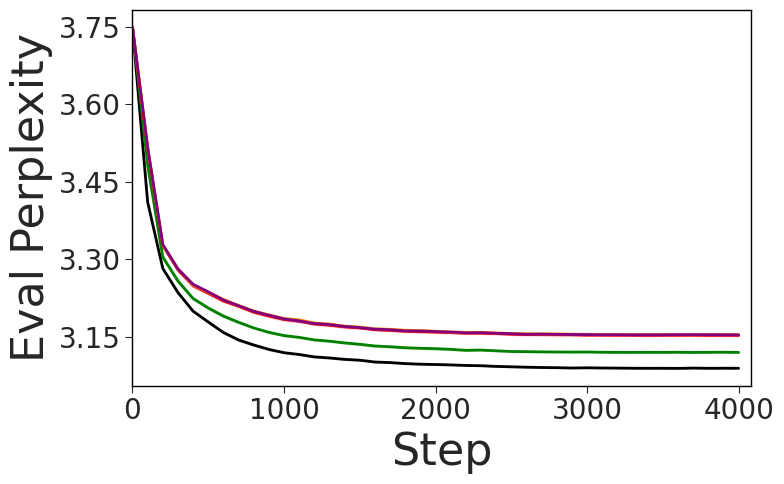


  dolci-instruction → precise IF (k=0.5)
  [Full] + FullTraining: 5 seeds, final ppl=3.089
  [Full] + GlobalSubset: 5 seeds, final ppl=3.098
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.118
  [Full] + BlockWiseSubset: 5 seeds, final ppl=3.119
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=3.120
    -> ./figures/dolci_inst_if_k50_Full.pdf


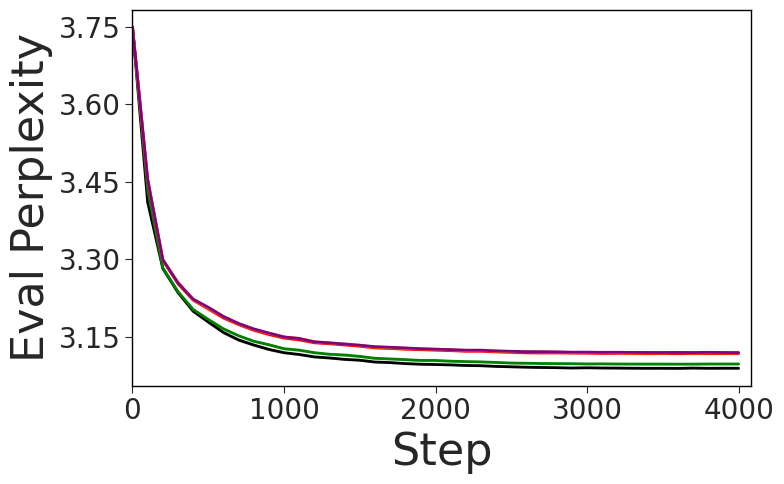


  dolci-instruction → precise IF (k=0.75)
  [Full] + FullTraining: 5 seeds, final ppl=3.089
  [Full] + GlobalSubset: 5 seeds, final ppl=3.089
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.096
  [Full] + BlockWiseSubset: 5 seeds, final ppl=3.097
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=3.097
    -> ./figures/dolci_inst_if_k75_Full.pdf


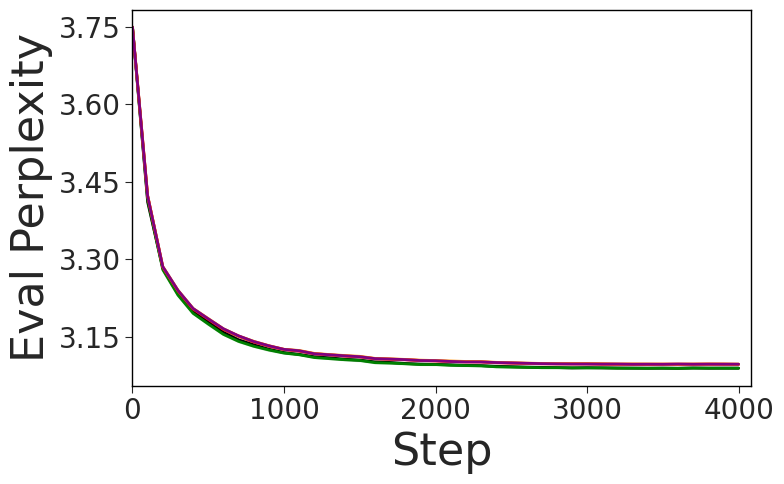


  dolci-mixed → precise IF (k=0.25)
  [Full] + FullTraining: 5 seeds, final ppl=3.123
  [Full] + GlobalSubset: 5 seeds, final ppl=3.143
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.168
    -> ./figures/dolci_mixed_if_k25_Full.pdf


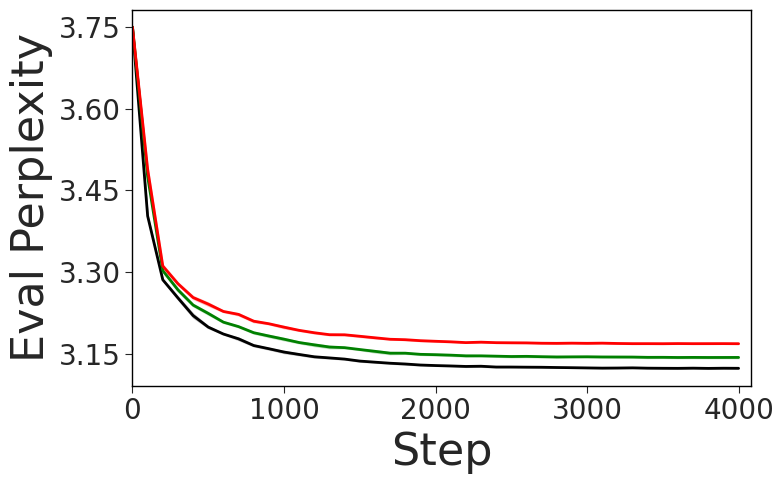


  dolci-mixed → precise IF (k=0.5)
  [Full] + FullTraining: 5 seeds, final ppl=3.123
  [Full] + GlobalSubset: 5 seeds, final ppl=3.126
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.135
    -> ./figures/dolci_mixed_if_k50_Full.pdf


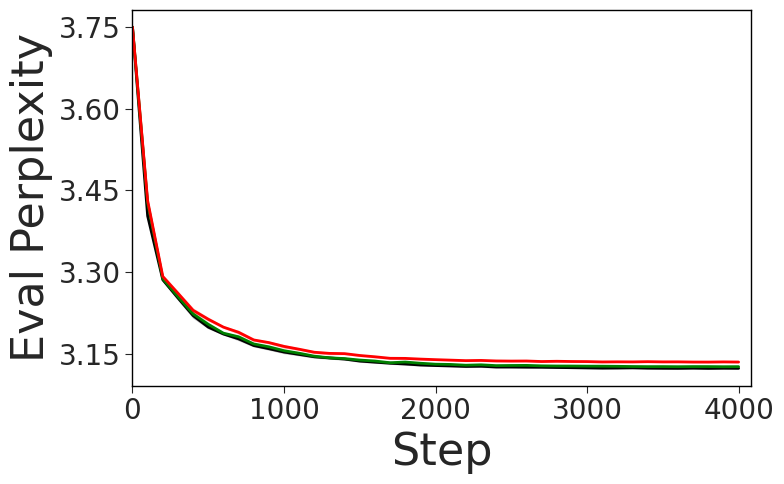


  dolci-mixed → precise IF (k=0.75)
  [Full] + FullTraining: 5 seeds, final ppl=3.123
  [Full] + GlobalSubset: 5 seeds, final ppl=3.123
  [Full] + LayerWiseSubset: 5 seeds, final ppl=3.126
    -> ./figures/dolci_mixed_if_k75_Full.pdf


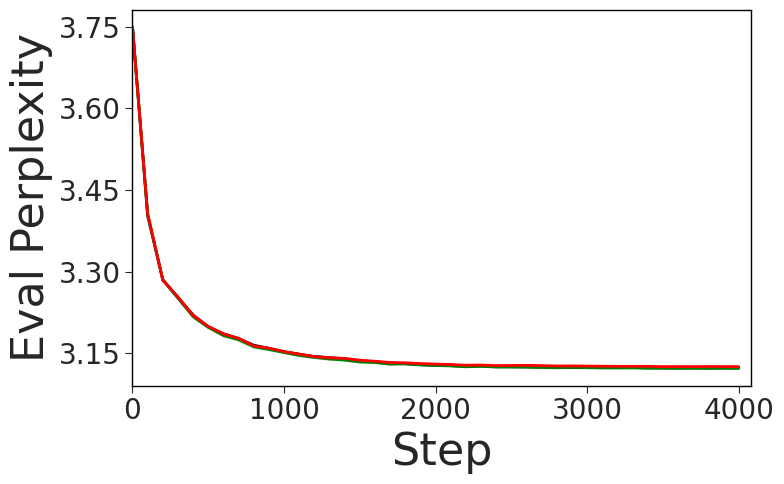


  dolci-reasoning → math (k=0.25)
  [Full] + FullTraining: 5 seeds, final ppl=1.298
  [Full] + GlobalSubset: 5 seeds, final ppl=1.302
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.306
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.307
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.306
    -> ./figures/dolci_reason_mathpersona_k25_Full.pdf


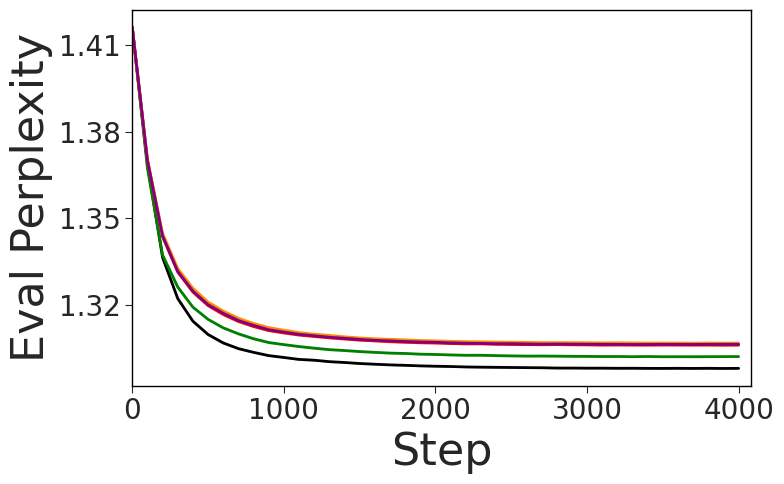


  dolci-reasoning → math (k=0.5)
  [Full] + FullTraining: 5 seeds, final ppl=1.298
  [Full] + GlobalSubset: 5 seeds, final ppl=1.300
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.301
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.301
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.301
    -> ./figures/dolci_reason_mathpersona_k50_Full.pdf


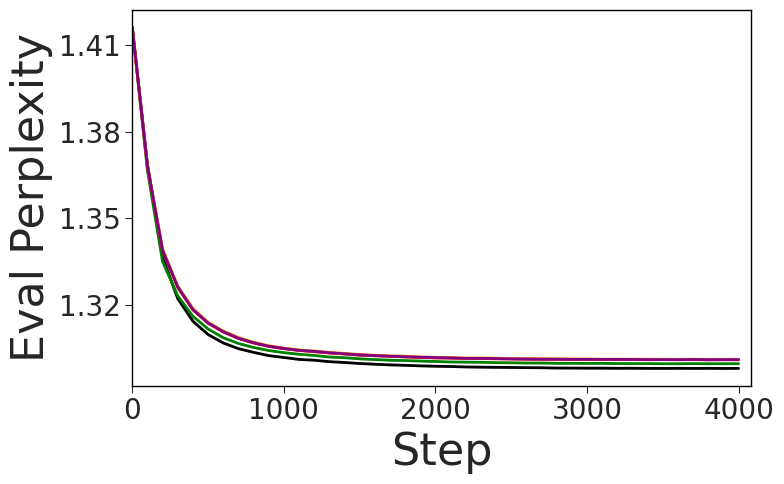


  dolci-reasoning → math (k=0.75)
  [Full] + FullTraining: 5 seeds, final ppl=1.298
  [Full] + GlobalSubset: 5 seeds, final ppl=1.299
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.299
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.299
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.299
    -> ./figures/dolci_reason_mathpersona_k75_Full.pdf


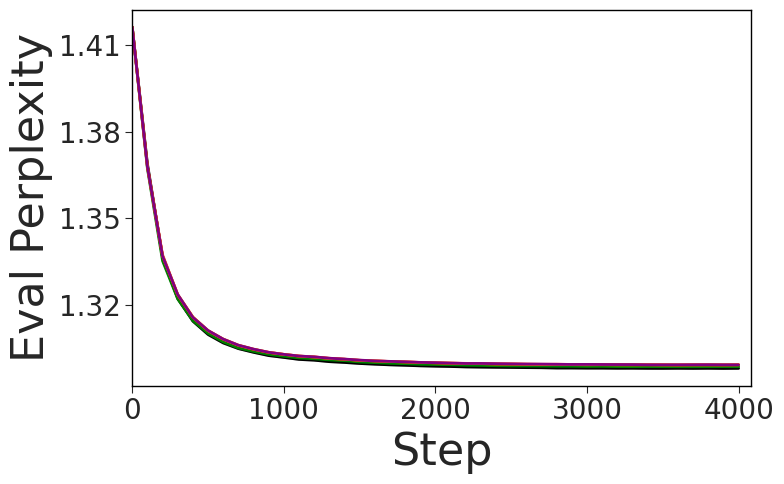


  dolci-mixed → math (k=0.25)
  [Full] + FullTraining: 5 seeds, final ppl=1.305
  [Full] + GlobalSubset: 5 seeds, final ppl=1.309
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.316
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.317
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.316
    -> ./figures/dolci_mixed_mathpersona_k25_Full.pdf


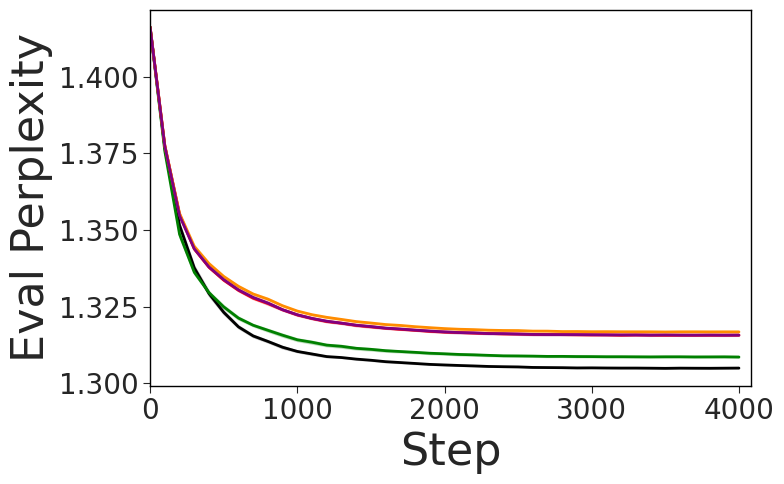


  dolci-mixed → math (k=0.5)
  [Full] + FullTraining: 5 seeds, final ppl=1.305
  [Full] + GlobalSubset: 5 seeds, final ppl=1.306
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.308
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.309
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.308
    -> ./figures/dolci_mixed_mathpersona_k50_Full.pdf


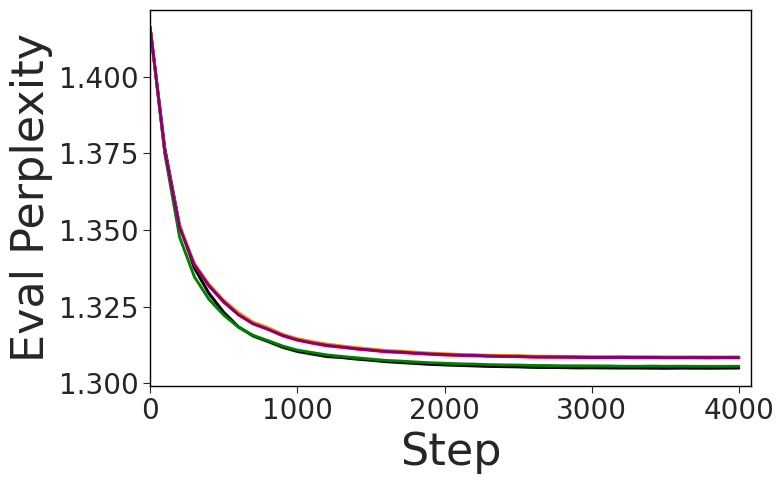


  dolci-mixed → math (k=0.75)
  [Full] + FullTraining: 5 seeds, final ppl=1.305
  [Full] + GlobalSubset: 5 seeds, final ppl=1.305
  [Full] + LayerWiseSubset: 5 seeds, final ppl=1.306
  [Full] + BlockWiseSubset: 5 seeds, final ppl=1.306
  [Full] + SublayerWiseSubset: 5 seeds, final ppl=1.306
    -> ./figures/dolci_mixed_mathpersona_k75_Full.pdf


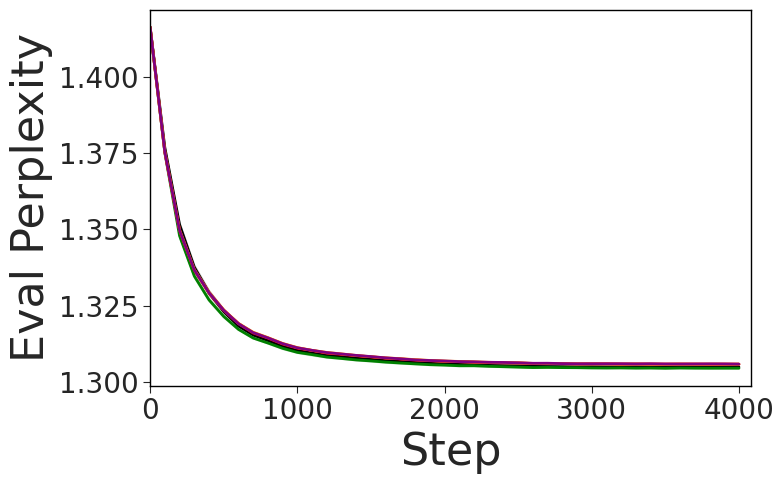


Saved legend: ./figures/legend.pdf


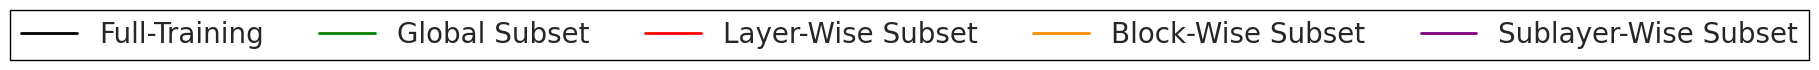

In [11]:
from matplotlib.ticker import MaxNLocator

# Per-(setting, ft) plots with shared y-limits within each setting.
# Target-only is excluded from these trajectory plots; only the curation
# methods in CURATIONS are drawn.
for ds in DATASETS:
    ds_key = ds_key_of(ds)
    main_traj = all_main.get(ds_key, {})

    print(f"\n{'=' * 60}\n  {DATASET_TITLES.get(ds_key, ds_key)}\n{'=' * 60}")

    # First pass: collect axis ranges across all FTs in this setting (main only).
    x_max, y_min, y_max = None, None, None
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None:
                continue
            mean = d['eval_perplexity_mean']
            std  = d['eval_perplexity_std']
            if d['n_seeds'] > 1:
                lo, hi = (mean - std).min(), (mean + std).max()
            else:
                lo, hi = mean.min(), mean.max()
            x_max = d['steps'].max() if x_max is None else max(x_max, d['steps'].max())
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)

    if x_max is None:
        print('  no data'); continue
    # Optional per-setting cap (e.g. clip triviaqa_nq's ~174 step-0 ppl baseline).
    cap = ds.get('y_clip_max_ppl')
    if cap is not None:
        y_max = min(y_max, cap)
        y_min = min(y_min, cap)
    y_pad = (y_max - y_min) * 0.05

    # Second pass: render one figure per FT.
    for ft in ds['finetunings']:
        per_ft = main_traj.get(ft, {})
        if not per_ft:
            print(f"  [{ft}] no main data"); continue

        fig, ax = plt.subplots(figsize=(8, 5))
        fig.patch.set_facecolor('white'); ax.set_facecolor('white')

        for cur in CURATIONS:
            d = per_ft.get(cur)
            if d is None:
                continue
            color = METHOD_COLORS[cur]
            ax.plot(d['steps'], d['eval_perplexity_mean'], lw=2, color=color, label=LEGEND_NAMES[cur])
            if d['n_seeds'] > 1:
                ax.fill_between(d['steps'], d['eval_perplexity_mean'] - d['eval_perplexity_std'],
                                d['eval_perplexity_mean'] + d['eval_perplexity_std'],
                                color=color, alpha=0.2)
            print(f"  [{ft}] + {cur}: {d['n_seeds']} seeds, final ppl={d['eval_perplexity_mean'][-1]:.3f}")

        ax.set_xlabel('Step', fontsize=32)
        if ft == ds['finetunings'][0]:
            ax.set_ylabel('Eval Perplexity', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for sp in ax.spines.values(): sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_xlim(left=0, right=x_max * 1.02)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        plt.tight_layout()
        path = os.path.join(save_dir, f'{ds_key}_{ft}.pdf')
        fig.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"    -> {path}")
        plt.show()

# Standalone legend (one canonical version for all curation methods in CURATIONS).
legend_specs = [(LEGEND_NAMES[c], METHOD_COLORS[c], '-') for c in CURATIONS]
fig_leg, ax_leg = plt.subplots(figsize=(2.6 * len(legend_specs), 0.5))
ax_leg.set_axis_off(); fig_leg.patch.set_facecolor('white')
handles = [plt.Line2D([0], [0], color=c, lw=2, linestyle=ls) for _, c, ls in legend_specs]
labels  = [n for n, _, _ in legend_specs]
legend = fig_leg.legend(handles, labels, loc='center', ncol=len(labels),
                        fontsize=20, frameon=True, edgecolor='black',
                        fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
path = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {path}")
plt.show()


## Paper Figures: Eval Loss vs Step (linear-scale companion)

Same data, but eval loss on a linear scale instead of perplexity on log scale. Useful when the perplexity tail dominates the visual range.


  -> ./figures/dolci_inst_if_k25_Full_loss.pdf


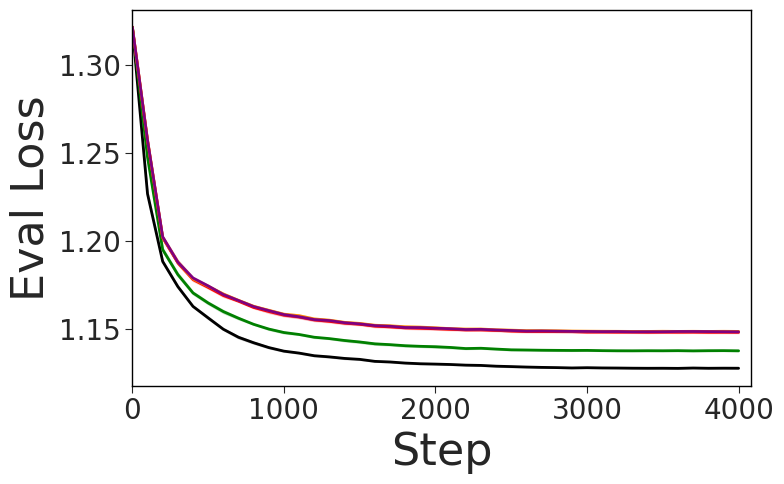

  -> ./figures/dolci_inst_if_k50_Full_loss.pdf


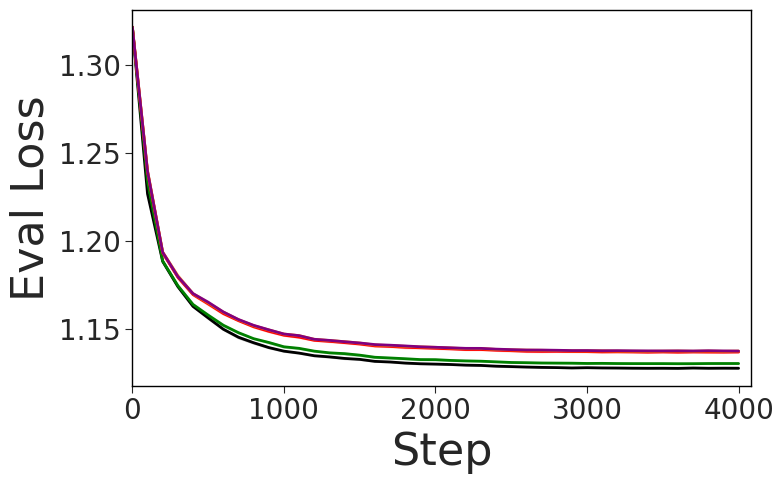

  -> ./figures/dolci_inst_if_k75_Full_loss.pdf


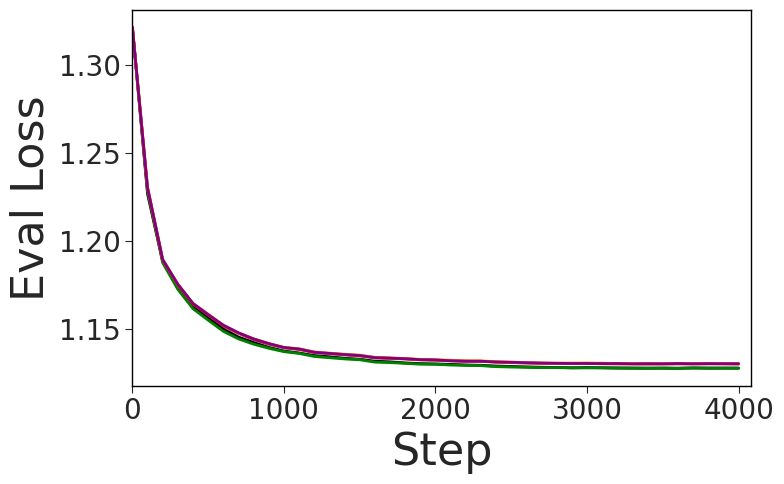

  -> ./figures/dolci_mixed_if_k25_Full_loss.pdf


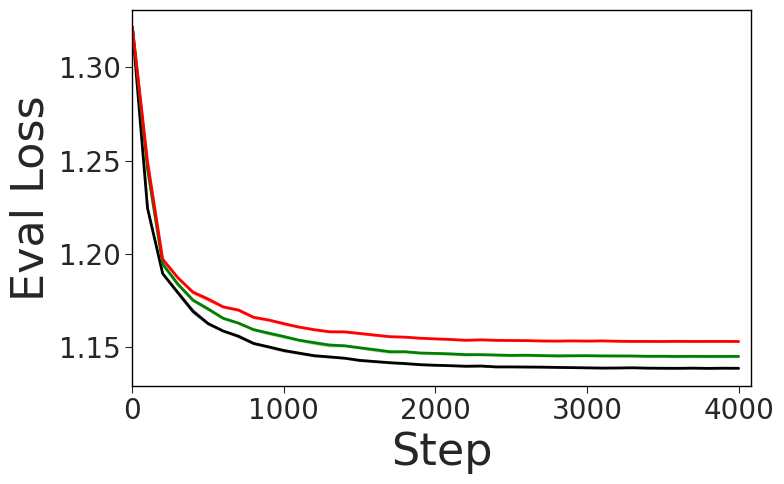

  -> ./figures/dolci_mixed_if_k50_Full_loss.pdf


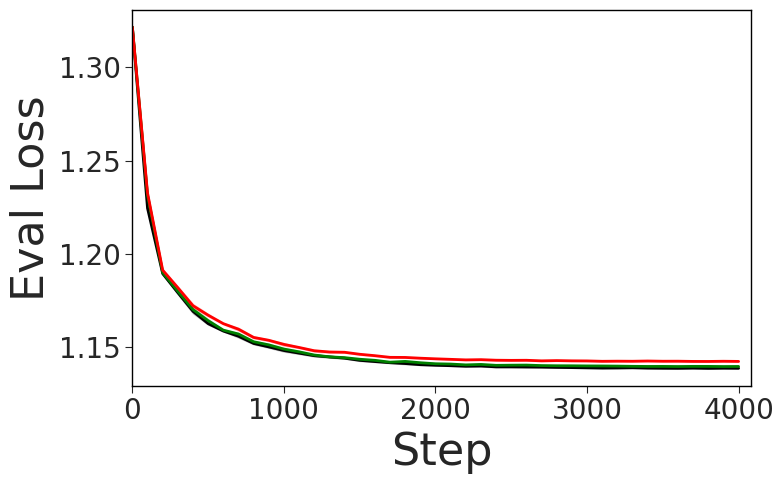

  -> ./figures/dolci_mixed_if_k75_Full_loss.pdf


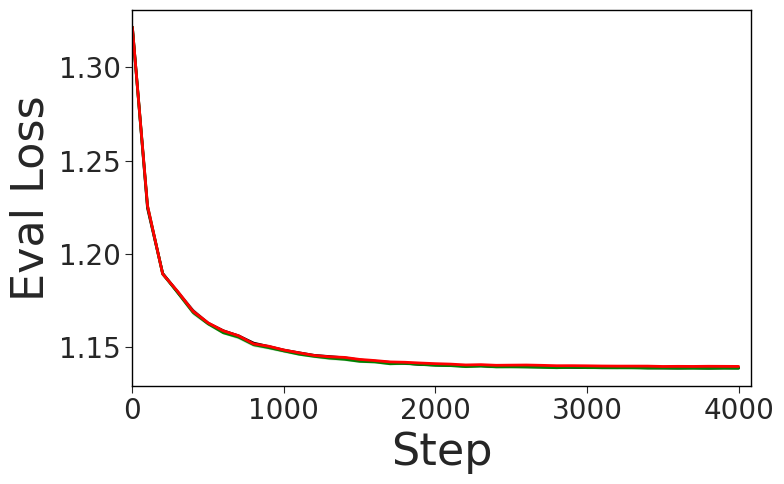

  -> ./figures/dolci_reason_mathpersona_k25_Full_loss.pdf


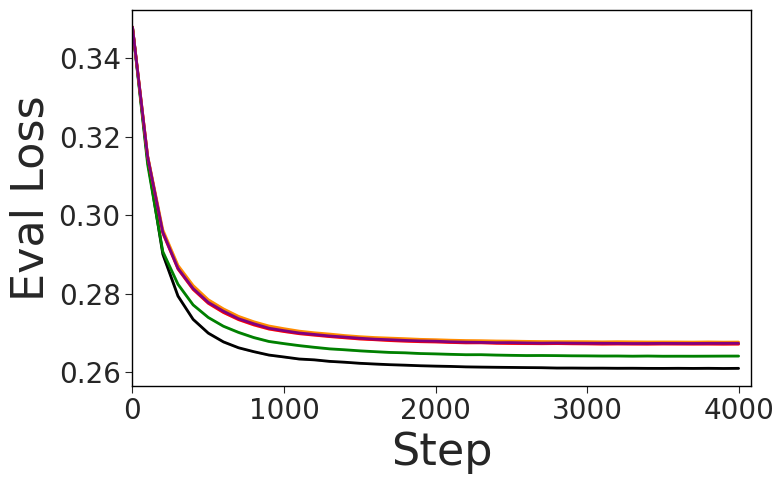

  -> ./figures/dolci_reason_mathpersona_k50_Full_loss.pdf


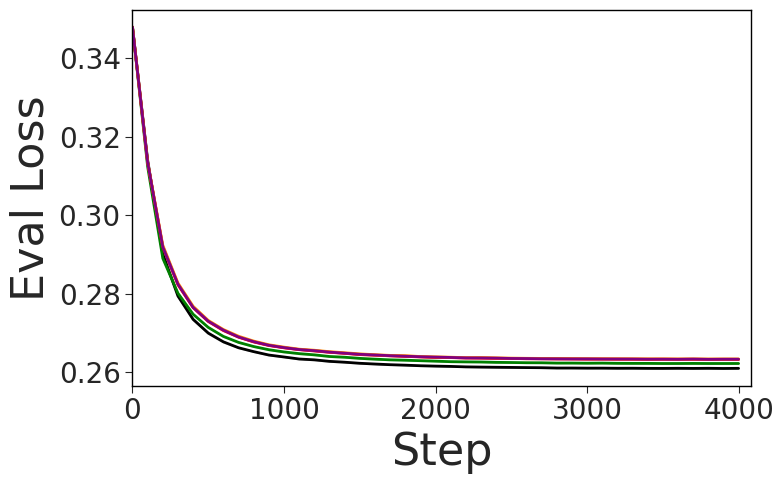

  -> ./figures/dolci_reason_mathpersona_k75_Full_loss.pdf


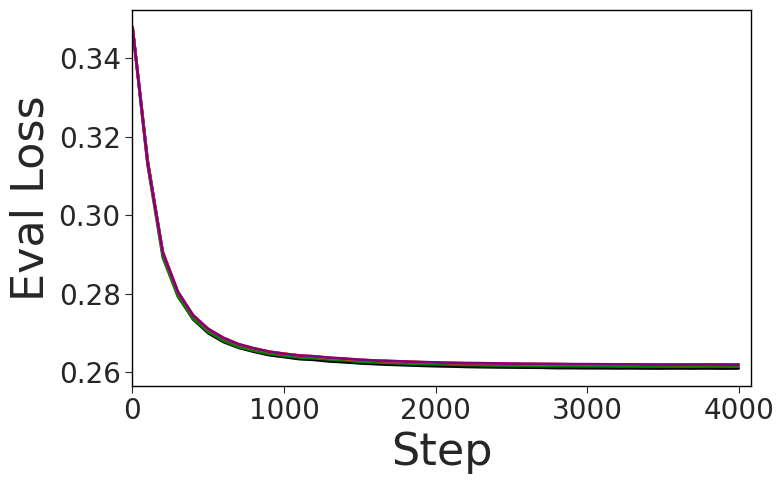

  -> ./figures/dolci_mixed_mathpersona_k25_Full_loss.pdf


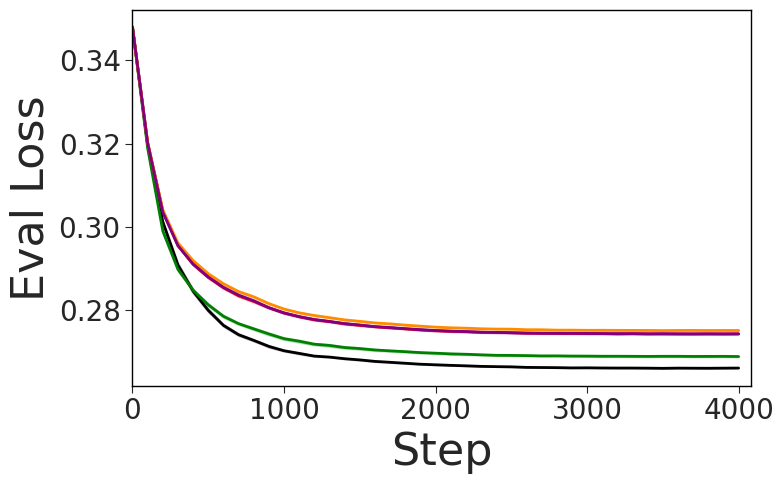

  -> ./figures/dolci_mixed_mathpersona_k50_Full_loss.pdf


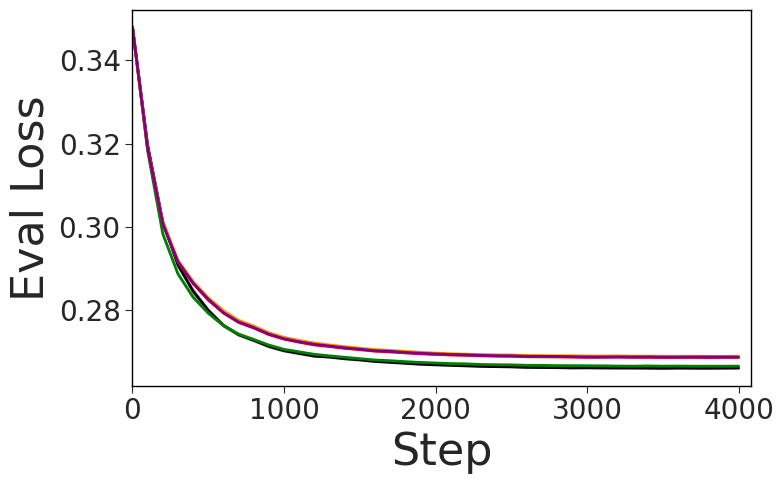

  -> ./figures/dolci_mixed_mathpersona_k75_Full_loss.pdf


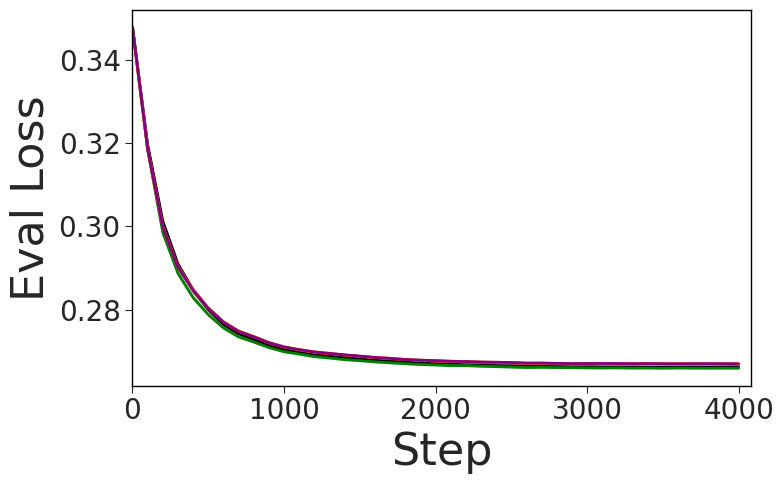

In [12]:
for ds in DATASETS:
    ds_key = ds_key_of(ds)
    main_traj = all_main.get(ds_key, {})

    # Shared y-limits in eval_loss across this setting's FTs (main only).
    x_max = y_min = y_max = None
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None: continue
            mean, std = d['eval_loss_mean'], d['eval_loss_std']
            lo, hi = ((mean - std).min(), (mean + std).max()) if d['n_seeds'] > 1 else (mean.min(), mean.max())
            x_max = d['steps'].max() if x_max is None else max(x_max, d['steps'].max())
            y_min = lo if y_min is None else min(y_min, lo)
            y_max = hi if y_max is None else max(y_max, hi)
    if x_max is None: continue
    cap = ds.get('y_clip_max_loss')
    if cap is not None:
        y_max = min(y_max, cap)
        y_min = min(y_min, cap)
    y_pad = (y_max - y_min) * 0.05

    for ft in ds['finetunings']:
        per_ft = main_traj.get(ft, {})
        if not per_ft: continue

        fig, ax = plt.subplots(figsize=(8, 5))
        fig.patch.set_facecolor('white'); ax.set_facecolor('white')

        for cur in CURATIONS:
            d = per_ft.get(cur)
            if d is None: continue
            color = METHOD_COLORS[cur]
            ax.plot(d['steps'], d['eval_loss_mean'], lw=2, color=color, label=LEGEND_NAMES[cur])
            if d['n_seeds'] > 1:
                ax.fill_between(d['steps'], d['eval_loss_mean'] - d['eval_loss_std'],
                                d['eval_loss_mean'] + d['eval_loss_std'],
                                color=color, alpha=0.2)

        ax.set_xlabel('Step', fontsize=32)
        if ft == ds['finetunings'][0]:
            ax.set_ylabel('Eval Loss', fontsize=32)
        ax.grid(True, alpha=0.3, linewidth=0.5)
        for sp in ax.spines.values(): sp.set_visible(True); sp.set_linewidth(1.0); sp.set_color('black')
        ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.set_xlim(left=0, right=x_max * 1.02)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)

        plt.tight_layout()
        path = os.path.join(save_dir, f'{ds_key}_{ft}_loss.pdf')
        fig.savefig(path, format='pdf', bbox_inches='tight', facecolor='white')
        print(f"  -> {path}")
        plt.show()


## Results Tables: Task-Specific Metrics

Final-checkpoint downstream metric (mean ± SE over 5 seeds).


In [13]:
for ds in DATASETS:
    ds_key = ds_key_of(ds)
    metric_traj = all_main_metric.get(ds_key, {})
    target_metric = all_target_metric.get(ds_key, {})

    spec = TASK_METRICS.get(ds['task'])
    if spec is None: continue
    primary = spec['primary']
    metrics = [primary] + [m for m in task_metric_specs(ds['task']) if m != primary]

    print(f"\n{DATASET_TITLES.get(ds_key, ds_key):<40} (primary: {primary})")
    print('=' * (40 + 22 * len(metrics)))
    print(f"  {'method':<26}" + ''.join(f" {m + ' (mean ± SE)':>21}" for m in metrics) + "  (n)")

    for ft in ds['finetunings']:
        rows = []
        for cur in CURATIONS:
            d = metric_traj.get(ft, {}).get(cur)
            if d and f'{primary}_mean' in d:
                rows.append((f'{cur}-{ft}', d))
        td = target_metric.get(ft)
        if td and f'{primary}_mean' in td:
            rows.append((f'Target-only-{ft}', td))
        if not rows: continue
        print(f"  -- {ft} --")
        for name, d in rows:
            cells = ''.join(f" {d[f'{m}_mean']:>12.3f} ± {d[f'{m}_se']:>6.3f}" if f'{m}_mean' in d else f" {'-':>21}" for m in metrics)
            print(f"  {name:<26}{cells}  (n={d[f'{primary}_n']})")



dolci-instruction → precise IF (k=0.25)  (primary: ifeval_strict)
  method                     ifeval_strict (mean ± SE) ifeval_loose (mean ± SE) ifbench_loose (mean ± SE) ifbench_strict (mean ± SE)  (n)
  -- Full --
  FullTraining-Full                44.843 ±  0.345       48.022 ±  0.406       19.733 ±  0.273       15.467 ±  0.242  (n=5)
  GlobalSubset-Full                42.107 ±  0.429       45.730 ±  0.254       19.133 ±  0.530       14.467 ±  0.547  (n=5)
  LayerWiseSubset-Full             39.224 ±  0.694       43.438 ±  0.488       17.933 ±  0.318       13.733 ±  0.436  (n=5)
  BlockWiseSubset-Full             38.928 ±  0.436       42.773 ±  0.400       17.600 ±  0.370       13.000 ±  0.313  (n=5)
  SublayerWiseSubset-Full          38.669 ±  0.886       43.031 ±  0.792       17.467 ±  0.458       13.267 ±  0.273  (n=5)
  Target-only-Full                 39.704 ±  0.356       44.214 ±  0.160       21.733 ±  0.656       15.600 ±  0.345  (n=5)

dolci-instruction → precise IF (k=0.5

## PPL Summary

Min / final / ratio across step trajectories (mean over 5 seeds). Ratio > 1 indicates overfitting (final ppl above the trajectory minimum).


In [14]:
for ds in DATASETS:
    ds_key = ds_key_of(ds)
    main_traj   = all_main.get(ds_key, {})
    target_traj = all_target.get(ds_key, {})

    print(f"\n{DATASET_TITLES.get(ds_key, ds_key)}")
    print(f"{'finetuning':<8} {'method':<18} {'min_ppl':>9} {'fin_ppl':>10} {'ratio':>8}")
    print('-' * 60)
    for ft in ds['finetunings']:
        for cur in CURATIONS:
            d = main_traj.get(ft, {}).get(cur)
            if d is None: continue
            m = d['eval_perplexity_mean']
            print(f"{ft:<8} {cur:<18} {m.min():>9.3f} {m[-1]:>10.3f} {m[-1] / m.min():>7.2f}x")
        td = target_traj.get(ft)
        if td is not None:
            m = td['eval_perplexity_mean']
            print(f"{ft:<8} {'Target-only':<18} {m.min():>9.3f} {m[-1]:>10.3f} {m[-1] / m.min():>7.2f}x")
        print()



dolci-instruction → precise IF (k=0.25)
finetuning method               min_ppl    fin_ppl    ratio
------------------------------------------------------------
Full     FullTraining           3.089      3.089    1.00x
Full     GlobalSubset           3.120      3.120    1.00x
Full     LayerWiseSubset        3.153      3.153    1.00x
Full     BlockWiseSubset        3.154      3.154    1.00x
Full     SublayerWiseSubset     3.154      3.154    1.00x
Full     Target-only            3.246     25.738    7.93x


dolci-instruction → precise IF (k=0.5)
finetuning method               min_ppl    fin_ppl    ratio
------------------------------------------------------------
Full     FullTraining           3.089      3.089    1.00x
Full     GlobalSubset           3.097      3.098    1.00x
Full     LayerWiseSubset        3.117      3.118    1.00x
Full     BlockWiseSubset        3.119      3.119    1.00x
Full     SublayerWiseSubset     3.120      3.120    1.00x
Full     Target-only            3.246 